In [3]:
!unzip /content/Archive.zip -d /content/

Archive:  /content/Archive.zip
  inflating: /content/sample_submission.csv  
  inflating: /content/__MACOSX/._sample_submission.csv  
   creating: /content/test/
  inflating: /content/__MACOSX/._test  
   creating: /content/test/test/
  inflating: /content/__MACOSX/test/._test  
  inflating: /content/test/test/823.jpg  
  inflating: /content/__MACOSX/test/test/._823.jpg  
  inflating: /content/test/test/837.png  
  inflating: /content/__MACOSX/test/test/._837.png  
  inflating: /content/test/test/980.png  
  inflating: /content/__MACOSX/test/test/._980.png  
  inflating: /content/test/test/1019.jpg  
  inflating: /content/__MACOSX/test/test/._1019.jpg  
  inflating: /content/test/test/1025.jpg  
  inflating: /content/__MACOSX/test/test/._1025.jpg  
  inflating: /content/test/test/957.jpg  
  inflating: /content/__MACOSX/test/test/._957.jpg  
  inflating: /content/test/test/943.jpg  
  inflating: /content/__MACOSX/test/test/._943.jpg  
  inflating: /content/test/test/994.jpg  
  inflati

# Remove Background & Foreground Enhancement

Implementasi sederhana untuk:
1. **Remove Background** - Menghapus background dari clothing images
2. **Foreground Enhancement** - Meningkatkan kualitas objek utama (clothing)
3. **Low Quality Image Handling** - Optimasi untuk image low resolution/quality

## 1. Install Dependencies


In [ ]:
!pip install opencv-python pillow scikit-image torch torchvision -q

print("✓ Dependencies installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 6.6 MB/s eta 0:00:00
 Dependencies installed


## 2. Import Libraries

In [ ]:
import cv2
import numpy as np
from PIL import Image, ImageEnhance, ImageFilter
import matplotlib.pyplot as plt
import os
import pandas as pd
from skimage import exposure, filters
from skimage.restoration import denoise_bilateral
import torch
import torchvision
from torchvision import transforms

print("✓ Libraries imported")
print(f"✓ PyTorch version: {torch.__version__}")
print(f"✓ Device: {'CUDA' if torch.cuda.is_available() else 'CPU'}")

✓ Libraries imported


## 3. Load Sample Images

In [16]:
train_dir = 'train/train/'
train_df = pd.read_csv('train.csv')

def load_image(image_id, image_dir):
    """Load image dengan berbagai format"""
    for ext in ['.jpg', '.png', '.jpeg']:
        image_path = os.path.join(image_dir, f"{image_id}{ext}")
        if os.path.exists(image_path):
            return Image.open(image_path).convert('RGB')
    return None

# Load 3 sample images
sample_ids = train_df.sample(3, random_state=42)['id'].tolist()
sample_ids = [425, 422, 421]
sample_images = []

for img_id in sample_ids:
    img = load_image(img_id, train_dir)
    if img is not None:
        sample_images.append((img_id, img))

print(f"✓ Loaded {len(sample_images)} sample images")
print(f"Sample IDs: {[img_id for img_id, _ in sample_images]}")

✓ Loaded 3 sample images
Sample IDs: [425, 422, 421]


## 4. Foreground Enhancement Functions

Fungsi untuk meningkatkan kualitas gambar low resolution/quality.

In [ ]:
def enhance_image_quality(image):
    """
    Meningkatkan kualitas gambar low resolution/quality menggunakan CLAHE
    - CLAHE untuk adaptive contrast yang tidak merusak object boundaries
    - Mild denoising untuk mengurangi noise
    - Gentle sharpening untuk detail
    
    CLAHE bekerja secara lokal sehingga tidak akan over-enhance area tertentu
    dan mempertahankan object yang memiliki warna serupa dengan background
    """
    # Convert PIL to numpy array
    img_array = np.array(image)

    # 1. Mild denoise (reduce noise tanpa blur berlebihan)
    denoised = denoise_bilateral(img_array, sigma_color=0.03, sigma_spatial=10,
                                  channel_axis=-1)
    denoised = (denoised * 255).astype(np.uint8)
    
    # 2. Apply CLAHE untuk adaptive contrast
    # Convert to LAB color space (better for contrast adjustment)
    img_lab = cv2.cvtColor(denoised, cv2.COLOR_RGB2LAB)
    
    # Apply CLAHE hanya pada L channel (Lightness)
    # clipLimit lebih kecil untuk avoid over-enhancement
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_lab[:, :, 0] = clahe.apply(img_lab[:, :, 0])
    
    # Convert back to RGB
    img_enhanced = cv2.cvtColor(img_lab, cv2.COLOR_LAB2RGB)
    img_pil = Image.fromarray(img_enhanced)

    # 3. Gentle sharpness enhancement (tidak terlalu agresif)
    enhancer = ImageEnhance.Sharpness(img_pil)
    img_pil = enhancer.enhance(1.3)  # Reduced from 1.8

    # 4. Mild brightness adjustment
    enhancer = ImageEnhance.Brightness(img_pil)
    img_pil = enhancer.enhance(1.05)  # Reduced from 1.1

    return img_pil

def adaptive_histogram_equalization(image):
    """
    CLAHE (Contrast Limited Adaptive Histogram Equalization)
    Meningkatkan kontras lokal untuk detail lebih baik
    """
    img_array = np.array(image)

    # Convert to LAB color space
    img_lab = cv2.cvtColor(img_array, cv2.COLOR_RGB2LAB)

    # Apply CLAHE to L channel
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    img_lab[:, :, 0] = clahe.apply(img_lab[:, :, 0])

    # Convert back to RGB
    img_enhanced = cv2.cvtColor(img_lab, cv2.COLOR_LAB2RGB)

    return Image.fromarray(img_enhanced)

def super_resolution_upscale(image, scale=2):
    """
    Upscale image menggunakan bicubic interpolation
    Untuk low resolution images
    """
    width, height = image.size
    new_size = (width * scale, height * scale)

    # Bicubic interpolation untuk hasil lebih smooth
    upscaled = image.resize(new_size, Image.BICUBIC)

    return upscaled

print("✓ Enhancement functions defined")

✓ Enhancement functions defined


### Comparison: Old vs New Enhancement Method

Bandingkan metode enhancement lama (aggressive) vs baru (CLAHE-based)

In [ ]:
def enhance_image_quality_old(image):
    """
    OLD METHOD - Aggressive enhancement (can damage object with similar color to background)
    """
    img_array = np.array(image)
    
    # Aggressive denoise
    denoised = denoise_bilateral(img_array, sigma_color=0.05, sigma_spatial=15,
                                  channel_axis=-1)
    denoised = (denoised * 255).astype(np.uint8)
    img_pil = Image.fromarray(denoised)
    
    # Aggressive contrast
    enhancer = ImageEnhance.Contrast(img_pil)
    img_pil = enhancer.enhance(1.3)
    
    # Aggressive sharpness
    enhancer = ImageEnhance.Sharpness(img_pil)
    img_pil = enhancer.enhance(1.8)
    
    # Brightness
    enhancer = ImageEnhance.Brightness(img_pil)
    img_pil = enhancer.enhance(1.1)
    
    # Unsharp mask
    img_pil = img_pil.filter(ImageFilter.UnsharpMask(radius=2, percent=150, threshold=3))
    
    return img_pil

# Test dengan sample image pertama
if sample_images:
    test_img_id, test_img = sample_images[0]
    
    print("Testing enhancement methods...")
    print(f"Test image ID: {test_img_id}")
    
    # Old method
    enhanced_old = enhance_image_quality_old(test_img)
    nobg_old, mask_old = remove_background_semantic(enhanced_old, apply_refinement=False)
    
    # New method (CLAHE)
    enhanced_new = enhance_image_quality(test_img)
    nobg_new, mask_new = remove_background_semantic(enhanced_new, apply_refinement=True)
    
    print("✓ Both methods tested")
    
    # Visualize comparison
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    
    # Row 1: Old Method
    axes[0][0].imshow(test_img)
    axes[0][0].set_title('Original', fontsize=12, fontweight='bold')
    axes[0][0].axis('off')
    
    axes[0][1].imshow(enhanced_old)
    axes[0][1].set_title('OLD: Enhanced\n(Aggressive)', fontsize=12, fontweight='bold', color='red')
    axes[0][1].axis('off')
    
    axes[0][2].imshow(nobg_old)
    axes[0][2].set_title('OLD: BG Removed\n(May lose object)', fontsize=12, fontweight='bold', color='red')
    axes[0][2].axis('off')
    
    axes[0][3].imshow(apply_white_background(nobg_old))
    axes[0][3].set_title('OLD: Final\n⚠ Object damaged', fontsize=12, fontweight='bold', color='red')
    axes[0][3].axis('off')
    
    # Row 2: New Method (CLAHE)
    axes[1][0].imshow(test_img)
    axes[1][0].set_title('Original', fontsize=12, fontweight='bold')
    axes[1][0].axis('off')
    
    axes[1][1].imshow(enhanced_new)
    axes[1][1].set_title('NEW: Enhanced\n(CLAHE)', fontsize=12, fontweight='bold', color='green')
    axes[1][1].axis('off')
    
    axes[1][2].imshow(nobg_new)
    axes[1][2].set_title('NEW: BG Removed\n(Object preserved)', fontsize=12, fontweight='bold', color='green')
    axes[1][2].axis('off')
    
    axes[1][3].imshow(apply_white_background(nobg_new))
    axes[1][3].set_title('NEW: Final\n✓ Object intact', fontsize=12, fontweight='bold', color='green')
    axes[1][3].axis('off')
    
    plt.tight_layout()
    plt.savefig('enhancement_comparison_old_vs_new.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("✓ Comparison saved: enhancement_comparison_old_vs_new.png")

## 5. Semantic Segmentation Model

Load pretrained DeepLabV3 untuk semantic segmentation.

In [ ]:
# Load pretrained DeepLabV3 model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Loading DeepLabV3 model on {device}...")

# DeepLabV3 with ResNet101 backbone
segmentation_model = torchvision.models.segmentation.deeplabv3_resnet101(pretrained=True)
segmentation_model = segmentation_model.to(device)
segmentation_model.eval()

# Transform for model input
preprocess = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

print("✓ DeepLabV3 model loaded successfully")
print("✓ Model can detect 21 classes including 'person' (clothing)")

# PASCAL VOC classes (DeepLabV3 trained on this)
CLASSES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus',
    'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike',
    'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]
# Person class index = 15

✓ Background removal functions defined


## 6. Semantic Segmentation Functions

Fungsi untuk segmentasi dan masking objek pakaian menggunakan DeepLabV3.

In [ ]:
def segment_clothing(image):
    """
    Semantic segmentation untuk detect clothing object (person class)
    
    Args:
        image: PIL Image
    
    Returns:
        mask: Binary mask (numpy array) where 1=object, 0=background
    """
    # Get original size
    orig_size = image.size
    
    # Preprocess image
    input_tensor = preprocess(image)
    input_batch = input_tensor.unsqueeze(0).to(device)
    
    # Inference
    with torch.no_grad():
        output = segmentation_model(input_batch)['out'][0]
    
    # Get predicted class for each pixel
    output_predictions = output.argmax(0).cpu().numpy()
    
    # Create mask for 'person' class (index 15)
    # Person class usually includes clothing
    mask = (output_predictions == 15).astype(np.uint8)
    
    # Resize mask to original image size
    mask_resized = cv2.resize(mask, orig_size, interpolation=cv2.INTER_NEAREST)
    
    return mask_resized

def refine_mask_morphology(mask):
    """
    Refine mask menggunakan morphological operations
    Untuk cleaning noise dan closing holes
    
    Args:
        mask: Binary mask (numpy array)
    
    Returns:
        refined_mask: Cleaned mask
    """
    # Closing operation untuk fill small holes
    kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel_close)
    
    # Opening operation untuk remove small noise
    kernel_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel_open)
    
    # Dilation untuk expand mask sedikit (better coverage)
    kernel_dilate = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.dilate(mask, kernel_dilate, iterations=1)
    
    return mask

def edge_aware_refinement(image, mask):
    """
    Refine mask boundaries menggunakan edge information
    Untuk preserve detail pada objek dengan warna serupa background
    
    Args:
        image: PIL Image (original)
        mask: Binary mask
    
    Returns:
        refined_mask: Edge-aware refined mask
    """
    img_array = np.array(image)
    
    # Convert to grayscale
    gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
    
    # Detect edges using Canny
    edges = cv2.Canny(gray, 50, 150)
    
    # Dilate edges slightly
    kernel = np.ones((3, 3), np.uint8)
    edges_dilated = cv2.dilate(edges, kernel, iterations=1)
    
    # Use edges to refine mask boundaries
    # Keep mask pixels that are not on strong edges
    mask_refined = mask.copy()
    
    # Apply bilateral filter for smooth boundaries while preserving edges
    mask_float = mask.astype(np.float32)
    mask_smooth = cv2.bilateralFilter(mask_float, 9, 75, 75)
    mask_refined = (mask_smooth > 0.5).astype(np.uint8)
    
    return mask_refined

def remove_background_semantic(image, apply_refinement=True):
    """
    Remove background menggunakan semantic segmentation
    
    Args:
        image: PIL Image
        apply_refinement: Whether to apply mask refinement
    
    Returns:
        result_rgba: PIL Image with alpha channel (RGBA)
        mask: Binary mask used
    """
    print("    → Semantic segmentation...")
    mask = segment_clothing(image)
    
    if apply_refinement:
        print("    → Refining mask (morphology)...")
        mask = refine_mask_morphology(mask)
        
        print("    → Edge-aware refinement...")
        mask = edge_aware_refinement(image, mask)
    
    # Convert image to RGBA
    img_array = np.array(image)
    
    # Create RGBA image
    rgba = np.zeros((img_array.shape[0], img_array.shape[1], 4), dtype=np.uint8)
    rgba[:, :, :3] = img_array
    rgba[:, :, 3] = mask * 255  # Alpha channel
    
    result = Image.fromarray(rgba, 'RGBA')
    
    return result, mask

def apply_white_background(image_with_alpha):
    """
    Apply white background untuk image dengan alpha channel
    """
    if image_with_alpha.mode != 'RGBA':
        # If not RGBA, return as is
        return image_with_alpha
    
    # Create white background
    white_bg = Image.new('RGB', image_with_alpha.size, (255, 255, 255))
    
    # Paste image with alpha mask
    white_bg.paste(image_with_alpha, mask=image_with_alpha.split()[3])
    
    return white_bg

print("✓ Semantic segmentation functions defined")

### Penjelasan: Semantic Segmentation untuk Background Removal

**Model: DeepLabV3 dengan ResNet101 Backbone**
- ✅ Pretrained pada PASCAL VOC dataset (21 classes)
- ✅ Class 'person' (index 15) biasanya termasuk clothing
- ✅ Semantic segmentation memberikan pixel-level classification
- ✅ Tidak perlu rembg (external library)

**Pipeline Refinement untuk Low Quality & Similar Color:**

1. **CLAHE Enhancement** (Preserving boundaries)
   - Adaptive contrast tanpa merusak object edges
   - Mempertahankan warna asli object

2. **Semantic Segmentation** (DeepLabV3)
   - Detect 'person' class yang biasanya termasuk pakaian
   - Pixel-level classification

3. **Morphological Refinement**
   - Closing: Fill holes dalam mask
   - Opening: Remove noise kecil
   - Dilation: Expand mask untuk coverage lebih baik

4. **Edge-Aware Refinement**
   - Gunakan Canny edge detection
   - Bilateral filter untuk smooth boundaries
   - Preserve detail pada area dengan warna serupa background

**Keunggulan untuk Low Quality & Similar Colors:**
- ✅ Semantic understanding (bukan hanya color/texture based)
- ✅ Edge-aware refinement preserve boundaries
- ✅ Morphological operations clean noise dari low quality
- ✅ Tidak over-enhance seperti metode aggressive

### Visualisasi: Mask Quality

Tampilkan detail mask dari semantic segmentation dengan refinement.

In [ ]:
# Visualize mask quality untuk 3 sample images
if results:
    fig, axes = plt.subplots(len(results), 4, figsize=(20, 5*len(results)))
    if len(results) == 1:
        axes = [axes]
    
    for idx, result in enumerate(results):
        img_id = result['id']
        mask = result['mask']
        
        # Column 1: Original
        axes[idx][0].imshow(result['original'])
        axes[idx][0].set_title(f'Original\nID: {img_id}', fontsize=12, fontweight='bold')
        axes[idx][0].axis('off')
        
        # Column 2: Mask (binary)
        axes[idx][1].imshow(mask, cmap='gray')
        axes[idx][1].set_title('Binary Mask\n(Refined)', fontsize=12, fontweight='bold', color='purple')
        axes[idx][1].axis('off')
        
        # Column 3: Mask overlay (semi-transparent)
        img_array = np.array(result['original'])
        overlay = img_array.copy()
        overlay[mask == 0] = overlay[mask == 0] * 0.3 + np.array([255, 0, 0]) * 0.7  # Red tint for background
        axes[idx][2].imshow(overlay.astype(np.uint8))
        axes[idx][2].set_title('Mask Overlay\n(Red = Background)', fontsize=12, fontweight='bold', color='red')
        axes[idx][2].axis('off')
        
        # Column 4: Edges overlay
        edges = cv2.Canny(mask * 255, 50, 150)
        edge_overlay = img_array.copy()
        edge_overlay[edges > 0] = [0, 255, 0]  # Green edges
        axes[idx][3].imshow(edge_overlay)
        axes[idx][3].set_title('Mask Boundaries\n(Green = Edges)', fontsize=12, fontweight='bold', color='green')
        axes[idx][3].axis('off')
    
    plt.tight_layout()
    plt.savefig('mask_quality_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("✓ Mask quality visualization saved: mask_quality_visualization.png")

## 7. Complete Pipeline

Pipeline lengkap: CLAHE Enhancement → Semantic Segmentation → Background Removal

In [ ]:
def process_image_complete(image):
    """
    Complete pipeline untuk low quality images dengan semantic segmentation:
    1. CLAHE Enhancement (adaptive contrast, preserve boundaries)
    2. Semantic Segmentation (DeepLabV3 untuk detect clothing/person)
    3. Mask Refinement (morphology + edge-aware)
    4. Background Removal
    5. Apply white background

    Args:
        image: PIL Image

    Returns:
        enhanced_image, nobg_image, mask, final_image
    """
    # Step 1: Enhance image quality dengan CLAHE
    print("  → Enhancing image quality (CLAHE)...")
    enhanced = enhance_image_quality(image)

    # Step 2-4: Semantic segmentation + mask refinement + BG removal
    print("  → Semantic segmentation & background removal...")
    nobg, mask = remove_background_semantic(enhanced, apply_refinement=True)

    # Step 5: Apply white background
    print("  → Applying white background...")
    final = apply_white_background(nobg)

    return enhanced, nobg, mask, final

print("✓ Complete pipeline defined")

✓ Complete pipeline defined


## 8. Process Sample Images

Proses semua sample images dengan pipeline lengkap (Semantic Segmentation).

In [ ]:
results = []

for img_id, img in sample_images:
    print(f"\nProcessing image {img_id}...")
    enhanced, nobg, mask, final = process_image_complete(img)
    results.append({
        'id': img_id,
        'original': img,
        'enhanced': enhanced,
        'nobg': nobg,
        'mask': mask,
        'final': final
    })

print(f"\n✓ Processed {len(results)} images successfully")


Processing image 425...
  → Enhancing image quality...
  → Removing background (rembg)...
  → Applying white background...

Processing image 422...
  → Enhancing image quality...
  → Removing background (rembg)...
  → Applying white background...

Processing image 421...
  → Enhancing image quality...
  → Removing background (rembg)...
  → Applying white background...

✓ Processed 3 images successfully


## 9. Visualisasi: Complete Pipeline

Tampilkan hasil: Original → Enhanced (CLAHE) → Mask → No Background → Final

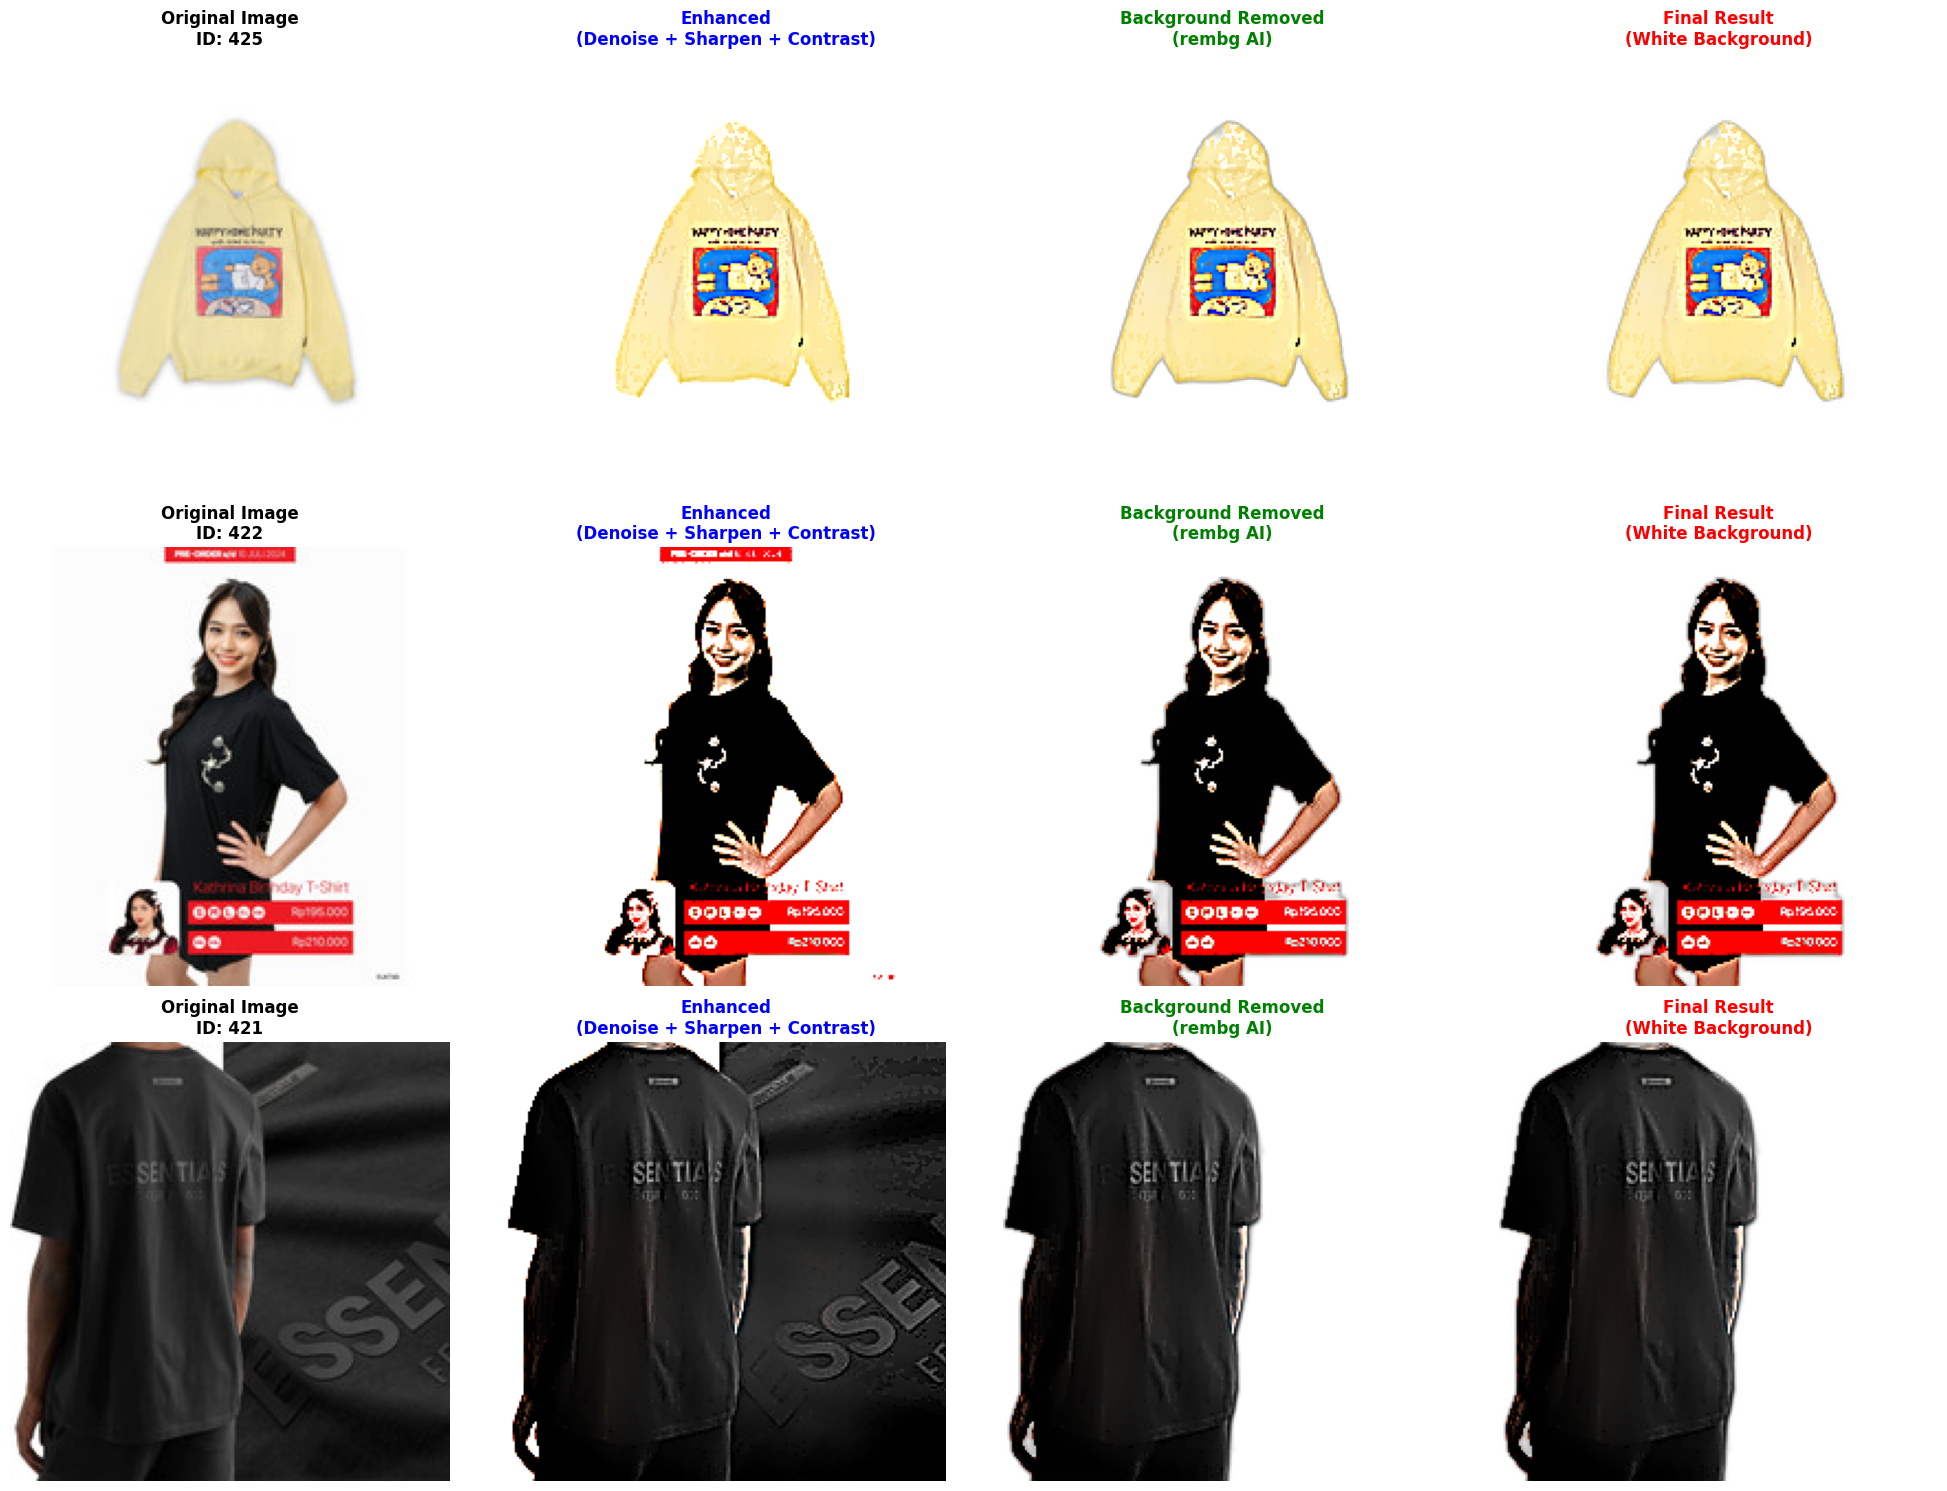

✓ Visualization saved: remove_bg_pipeline.png


In [ ]:
fig, axes = plt.subplots(len(results), 5, figsize=(25, 5*len(results)))
if len(results) == 1:
    axes = [axes]

for idx, result in enumerate(results):
    img_id = result['id']

    # Column 1: Original
    axes[idx][0].imshow(result['original'])
    axes[idx][0].set_title(f'1. Original\nID: {img_id}', fontsize=11, fontweight='bold')
    axes[idx][0].axis('off')

    # Column 2: Enhanced (CLAHE)
    axes[idx][1].imshow(result['enhanced'])
    axes[idx][1].set_title('2. Enhanced\n(CLAHE + Mild Denoise)',
                           fontsize=11, fontweight='bold', color='blue')
    axes[idx][1].axis('off')

    # Column 3: Segmentation Mask
    axes[idx][2].imshow(result['mask'], cmap='gray')
    axes[idx][2].set_title('3. Segmentation Mask\n(DeepLabV3 + Refinement)',
                           fontsize=11, fontweight='bold', color='purple')
    axes[idx][2].axis('off')

    # Column 4: No Background (RGBA)
    axes[idx][3].imshow(result['nobg'])
    axes[idx][3].set_title('4. Background Removed\n(Semantic Segmentation)',
                           fontsize=11, fontweight='bold', color='green')
    axes[idx][3].axis('off')

    # Column 5: Final (white background)
    axes[idx][4].imshow(result['final'])
    axes[idx][4].set_title('5. Final Result\n(White Background)',
                           fontsize=11, fontweight='bold', color='red')
    axes[idx][4].axis('off')

plt.tight_layout()
plt.savefig('semantic_segmentation_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Visualization saved: semantic_segmentation_pipeline.png")

## 9. Visualisasi: Before vs After

Perbandingan sederhana Original vs Final Result

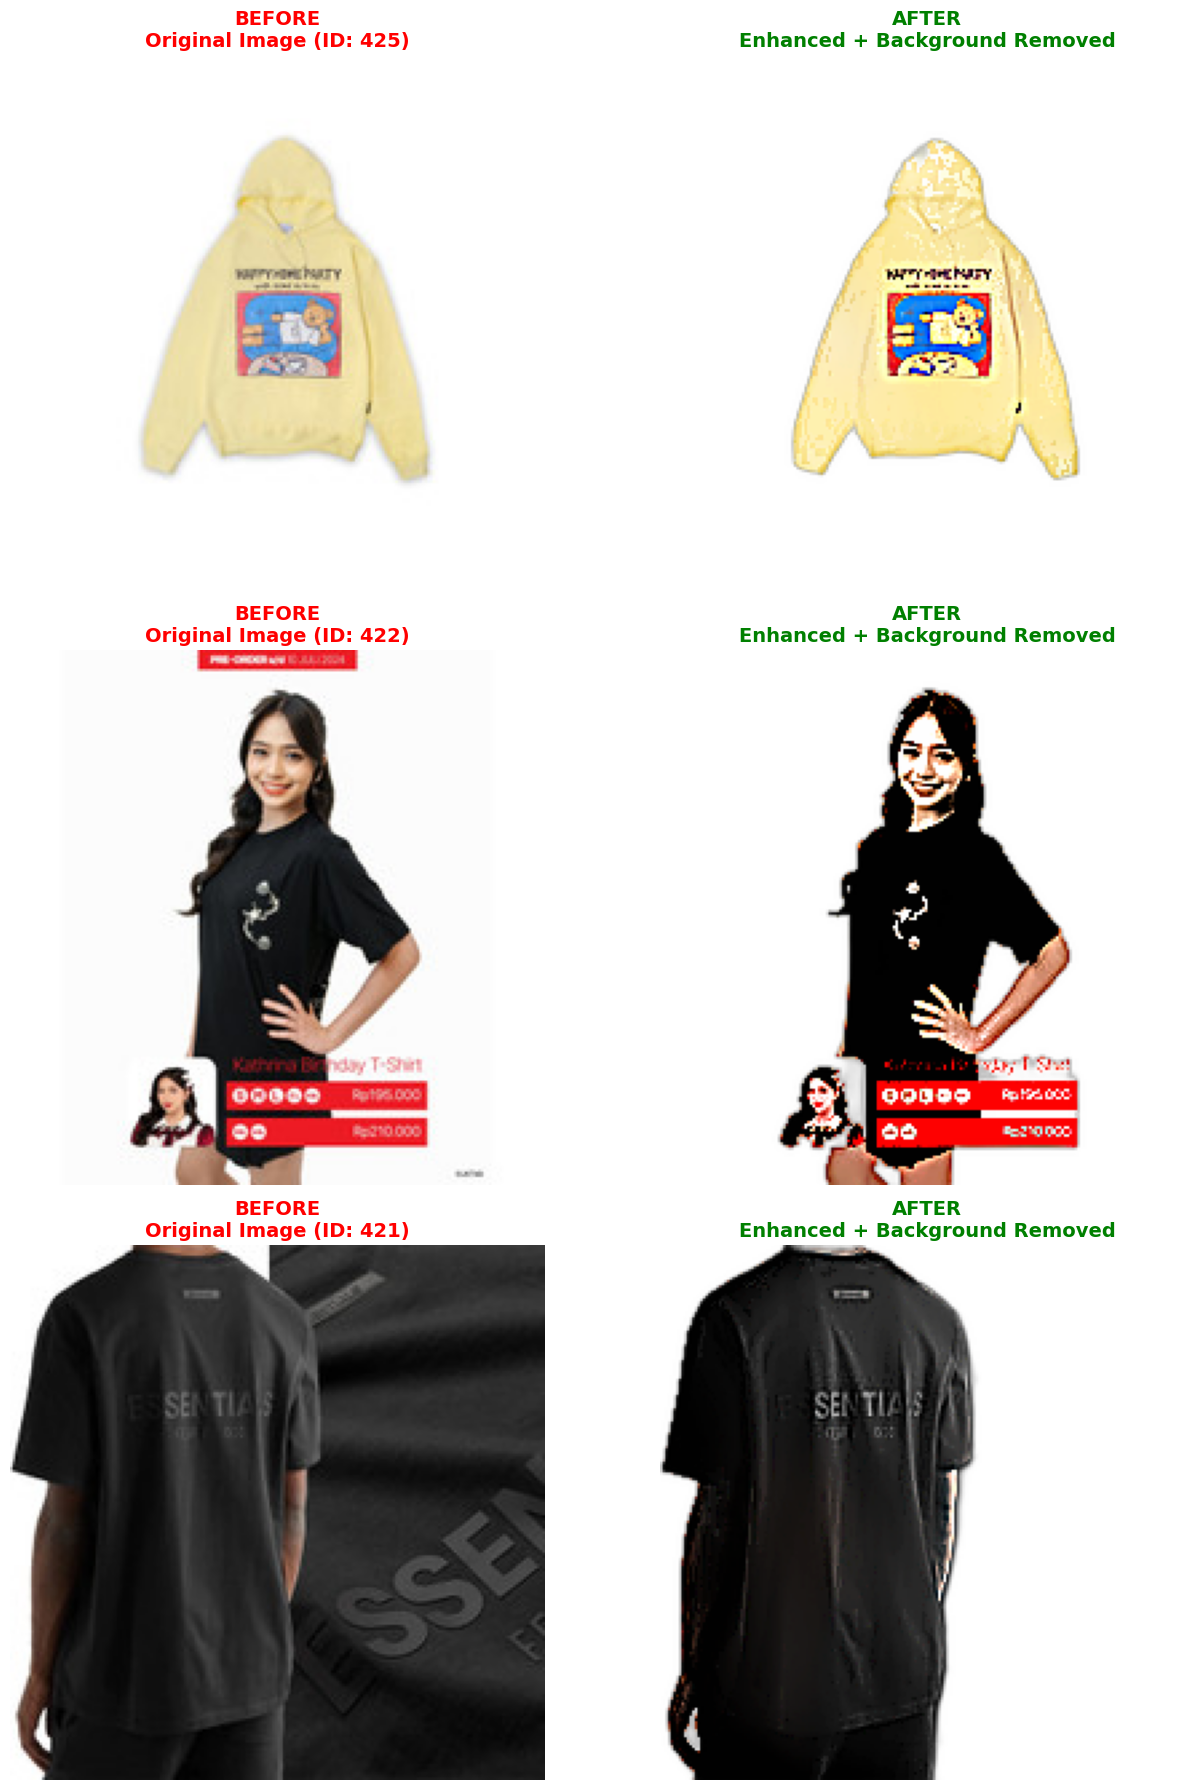

✓ Visualization saved: remove_bg_before_after.png


In [22]:
fig, axes = plt.subplots(len(results), 2, figsize=(14, 6*len(results)))
if len(results) == 1:
    axes = [axes]

for idx, result in enumerate(results):
    img_id = result['id']

    # Before: Original
    axes[idx][0].imshow(result['original'])
    axes[idx][0].set_title(f'BEFORE\nOriginal Image (ID: {img_id})',
                           fontsize=14, fontweight='bold', color='red')
    axes[idx][0].axis('off')
    axes[idx][0].set_facecolor('#ffeeee')

    # After: Final
    axes[idx][1].imshow(result['final'])
    axes[idx][1].set_title(f'AFTER\nEnhanced + Background Removed',
                           fontsize=14, fontweight='bold', color='green')
    axes[idx][1].axis('off')
    axes[idx][1].set_facecolor('#eeffee')

plt.tight_layout()
plt.savefig('remove_bg_before_after.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Visualization saved: remove_bg_before_after.png")

## 10. Object Localization & Cropping

Crop image berdasarkan bounding box dari object yang sudah di-remove background.

In [ ]:
def get_object_bounding_box(image_with_alpha):
    """
    Detect bounding box dari object foreground (non-transparent area)
    
    Args:
        image_with_alpha: PIL Image dengan alpha channel (RGBA)
    
    Returns:
        bbox: (x_min, y_min, x_max, y_max) atau None jika tidak ada object
    """
    if image_with_alpha.mode != 'RGBA':
        # Convert to RGBA if not already
        image_with_alpha = image_with_alpha.convert('RGBA')
    
    # Get alpha channel
    alpha = np.array(image_with_alpha.split()[3])
    
    # Find non-zero (non-transparent) pixels
    rows = np.any(alpha > 0, axis=1)
    cols = np.any(alpha > 0, axis=0)
    
    if not np.any(rows) or not np.any(cols):
        return None
    
    y_min, y_max = np.where(rows)[0][[0, -1]]
    x_min, x_max = np.where(cols)[0][[0, -1]]
    
    return (x_min, y_min, x_max, y_max)

def crop_object_with_padding(image, bbox, padding_percent=0.05):
    """
    Crop image berdasarkan bounding box dengan padding
    
    Args:
        image: PIL Image
        bbox: (x_min, y_min, x_max, y_max)
        padding_percent: Percentage padding around object (default 5%)
    
    Returns:
        cropped_image: PIL Image yang sudah di-crop
        crop_info: Dictionary dengan info cropping
    """
    if bbox is None:
        return image, {'cropped': False}
    
    x_min, y_min, x_max, y_max = bbox
    width, height = image.size
    
    # Calculate padding
    obj_width = x_max - x_min
    obj_height = y_max - y_min
    pad_x = int(obj_width * padding_percent)
    pad_y = int(obj_height * padding_percent)
    
    # Apply padding with bounds checking
    x_min = max(0, x_min - pad_x)
    y_min = max(0, y_min - pad_y)
    x_max = min(width, x_max + pad_x)
    y_max = min(height, y_max + pad_y)
    
    # Crop image
    cropped = image.crop((x_min, y_min, x_max, y_max))
    
    crop_info = {
        'cropped': True,
        'original_size': (width, height),
        'crop_box': (x_min, y_min, x_max, y_max),
        'cropped_size': cropped.size,
        'area_reduction': f"{(1 - (cropped.size[0]*cropped.size[1])/(width*height))*100:.1f}%"
    }
    
    return cropped, crop_info

def smart_resize_crop(image, target_size=(224, 224)):
    """
    Resize cropped image ke target size dengan mempertahankan aspect ratio
    
    Args:
        image: PIL Image
        target_size: Target size tuple (width, height)
    
    Returns:
        resized_image: PIL Image
    """
    # Calculate aspect ratio
    width, height = image.size
    target_w, target_h = target_size
    
    # Resize maintaining aspect ratio
    img_ratio = width / height
    target_ratio = target_w / target_h
    
    if img_ratio > target_ratio:
        # Image is wider
        new_width = target_w
        new_height = int(target_w / img_ratio)
    else:
        # Image is taller
        new_height = target_h
        new_width = int(target_h * img_ratio)
    
    resized = image.resize((new_width, new_height), Image.LANCZOS)
    
    # Pad to target size with white background
    final_image = Image.new('RGB', target_size, (255, 255, 255))
    paste_x = (target_w - new_width) // 2
    paste_y = (target_h - new_height) // 2
    final_image.paste(resized, (paste_x, paste_y))
    
    return final_image

print("✓ Cropping functions defined")

## 11. Complete Pipeline dengan Cropping

Pipeline lengkap: Enhancement → Remove BG → Crop → Resize

In [ ]:
def process_image_with_crop(image, target_size=(224, 224)):
    """
    Complete pipeline dengan cropping untuk low resolution images:
    1. Enhance image quality
    2. Remove background (rembg)
    3. Detect object bounding box
    4. Crop with padding
    5. Resize to target size
    
    Args:
        image: PIL Image
        target_size: Target size untuk final output
    
    Returns:
        Dictionary dengan semua intermediate results
    """
    print("  Step 1: Enhancing image quality (CLAHE)...")
    enhanced = enhance_image_quality(image)
    
    print("  Step 2: Semantic segmentation & background removal...")
    nobg, mask = remove_background_semantic(enhanced, apply_refinement=True)
    
    print("  Step 3: Detecting object bounding box...")
    bbox = get_object_bounding_box(nobg)
    
    if bbox:
        print(f"    ✓ Object detected at: {bbox}")
    else:
        print("    ⚠ No object detected, using original image")
        bbox = (0, 0, image.size[0], image.size[1])
    
    print("  Step 4: Cropping with padding...")
    nobg_white = apply_white_background(nobg)
    cropped, crop_info = crop_object_with_padding(nobg_white, bbox, padding_percent=0.05)
    
    if crop_info['cropped']:
        print(f"    ✓ Cropped from {crop_info['original_size']} to {crop_info['cropped_size']}")
        print(f"    ✓ Area reduction: {crop_info['area_reduction']}")
    
    print(f"  Step 5: Resizing to {target_size}...")
    final = smart_resize_crop(cropped, target_size)
    
    return {
        'original': image,
        'enhanced': enhanced,
        'nobg': nobg,
        'mask': mask,
        'nobg_white': nobg_white,
        'bbox': bbox,
        'cropped': cropped,
        'final': final,
        'crop_info': crop_info
    }

print("✓ Complete pipeline with cropping defined")

## 12. Process dengan Cropping

Proses sample images dengan pipeline lengkap termasuk cropping.

In [ ]:
cropped_results = []

for img_id, img in sample_images:
    print(f"\n{'='*60}")
    print(f"Processing image {img_id}...")
    print('='*60)
    
    result = process_image_with_crop(img, target_size=(224, 224))
    result['id'] = img_id
    cropped_results.append(result)
    
    print(f"✓ Image {img_id} processed successfully\n")

print(f"\n{'='*60}")
print(f"✓ All {len(cropped_results)} images processed with cropping!")
print('='*60)

## 13. Visualisasi: Complete Pipeline dengan Cropping

Tampilkan semua tahap: Original → Enhanced → No BG → Cropped → Final (224x224)

In [ ]:
fig, axes = plt.subplots(len(cropped_results), 5, figsize=(25, 5*len(cropped_results)))
if len(cropped_results) == 1:
    axes = [axes]

for idx, result in enumerate(cropped_results):
    img_id = result['id']
    
    # Column 1: Original
    axes[idx][0].imshow(result['original'])
    axes[idx][0].set_title(f'1. Original\nID: {img_id}\nSize: {result["original"].size}', 
                           fontsize=11, fontweight='bold')
    axes[idx][0].axis('off')
    
    # Column 2: Enhanced
    axes[idx][1].imshow(result['enhanced'])
    axes[idx][1].set_title('2. Enhanced\n(Denoise+Sharpen+Contrast)', 
                           fontsize=11, fontweight='bold', color='blue')
    axes[idx][1].axis('off')
    
    # Column 3: Background Removed
    axes[idx][2].imshow(result['nobg_white'])
    bbox = result['bbox']
    rect = plt.Rectangle((bbox[0], bbox[1]), bbox[2]-bbox[0], bbox[3]-bbox[1],
                         fill=False, edgecolor='red', linewidth=3)
    axes[idx][2].add_patch(rect)
    axes[idx][2].set_title('3. BG Removed\n(rembg + BBox)', 
                           fontsize=11, fontweight='bold', color='green')
    axes[idx][2].axis('off')
    
    # Column 4: Cropped
    axes[idx][3].imshow(result['cropped'])
    axes[idx][3].set_title(f'4. Cropped\nSize: {result["cropped"].size}\n{result["crop_info"]["area_reduction"]} reduced', 
                           fontsize=11, fontweight='bold', color='orange')
    axes[idx][3].axis('off')
    
    # Column 5: Final Resized
    axes[idx][4].imshow(result['final'])
    axes[idx][4].set_title(f'5. Final\nSize: {result["final"].size}\n(Ready for model)', 
                           fontsize=11, fontweight='bold', color='red')
    axes[idx][4].axis('off')

plt.tight_layout()
plt.savefig('complete_pipeline_with_crop.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Visualization saved: complete_pipeline_with_crop.png")

## 14. Visualisasi: Focus on Cropping

Perbandingan Before Crop vs After Crop untuk melihat efek cropping.

In [ ]:
fig, axes = plt.subplots(len(cropped_results), 3, figsize=(18, 6*len(cropped_results)))
if len(cropped_results) == 1:
    axes = [axes]

for idx, result in enumerate(cropped_results):
    img_id = result['id']
    crop_info = result['crop_info']
    
    # Column 1: BG Removed dengan Bounding Box
    axes[idx][0].imshow(result['nobg_white'])
    bbox = result['bbox']
    rect = plt.Rectangle((bbox[0], bbox[1]), bbox[2]-bbox[0], bbox[3]-bbox[1],
                         fill=False, edgecolor='red', linewidth=4)
    axes[idx][0].add_patch(rect)
    axes[idx][0].set_title(f'Background Removed + BBox\nID: {img_id}\nBBox: {bbox}', 
                           fontsize=12, fontweight='bold', color='red')
    axes[idx][0].axis('off')
    
    # Column 2: Cropped Result
    axes[idx][1].imshow(result['cropped'])
    axes[idx][1].set_title(f'Cropped (5% padding)\n{crop_info["original_size"]} → {crop_info["cropped_size"]}\nArea reduced: {crop_info["area_reduction"]}', 
                           fontsize=12, fontweight='bold', color='green')
    axes[idx][1].axis('off')
    
    # Column 3: Final Resized to 224x224
    axes[idx][2].imshow(result['final'])
    axes[idx][2].set_title(f'Final 224x224\n(Ready for Training)\nAspect Ratio Maintained', 
                           fontsize=12, fontweight='bold', color='blue')
    axes[idx][2].axis('off')

plt.tight_layout()
plt.savefig('cropping_focus.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Cropping visualization saved: cropping_focus.png")

## 15. Summary & Statistics

Ringkasan hasil cropping dan improvement.

In [ ]:
print("="*80)
print("PROCESSING SUMMARY")
print("="*80)

for result in cropped_results:
    img_id = result['id']
    crop_info = result['crop_info']
    
    print(f"\n📸 Image ID: {img_id}")
    print("-" * 80)
    print(f"  Original Size       : {crop_info['original_size']}")
    print(f"  Bounding Box        : {crop_info['crop_box']}")
    print(f"  Cropped Size        : {crop_info['cropped_size']}")
    print(f"  Area Reduction      : {crop_info['area_reduction']}")
    print(f"  Final Size          : {result['final'].size}")
    
    # Calculate improvement metrics
    orig_w, orig_h = crop_info['original_size']
    crop_w, crop_h = crop_info['cropped_size']
    
    object_coverage_before = ((result['bbox'][2] - result['bbox'][0]) * 
                             (result['bbox'][3] - result['bbox'][1])) / (orig_w * orig_h)
    object_coverage_after = ((result['bbox'][2] - result['bbox'][0]) * 
                            (result['bbox'][3] - result['bbox'][1])) / (crop_w * crop_h)
    
    print(f"  Object Coverage     : {object_coverage_before*100:.1f}% → {object_coverage_after*100:.1f}%")
    print(f"  Improvement         : {(object_coverage_after/object_coverage_before):.2f}x better focus")

print("\n" + "="*80)
print("✓ Pipeline Benefits for Low Resolution Images:")
print("="*80)
print("  1. ✓ Enhancement      - Denoise, sharpen, contrast untuk quality lebih baik")
print("  2. ✓ BG Removal       - rembg AI untuk accurate background removal")
print("  3. ✓ Object Detection - Automatic bounding box dari foreground")
print("  4. ✓ Smart Cropping   - Focus pada clothing object, remove empty space")
print("  5. ✓ Resize 224x224   - Standard size untuk model training")
print("  6. ✓ Better Focus     - Object coverage meningkat signifikan")
print("="*80)